This notebook is part of the `kikuchipy` documentation https://kikuchipy.org.
Links to the documentation won't work from the notebook.

# HR-EBSD of a silicon indent

The [HR-EBSD by digital image correlation](hrebsd_dic.ipynb) tutorial
measures a known deformation imposed on simulated patterns, and a noise
floor on a wafer scan acquired for something else.
This tutorial takes the same chain to a published, deformed data set
with a published answer: the nanoindent in single crystal silicon of
Winkelmann et al., *Ultramicroscopy* **276** (2025) 114180, whose raw
patterns are Zenodo record
[14059950](https://doi.org/10.5281/zenodo.14059950) (Cios and
Winkelmann, CC-BY-4.0).
The scan reproduces the indent conditions of
[Wilkinson and Britton (2012)](https://doi.org/10.1016/S1369-7021(12)70163-3):
a 250 by 234 point map at a 0.2 um step across the indent, with 622 by
512 pixel patterns, one per HDF5 chunk, lzf compressed with the shuffle
filter at a compression ratio of essentially one: the 18.9 GB on disk is
the 18.6 GB of pixels plus a filter pass on every one of the 58500 chunk
reads.

Two things make it the right data set for a replication rather than a
demonstration.

* The file carries the authors' **own result** beside the patterns: the
  strain tensor their MapSweeper refinement measured at every point.
  Our numbers can be compared with theirs component by component on the
  57685 points of 58500 where our own fit returns a number.
* The paper publishes a **method level noise floor** at exactly this
  pattern resolution, its Table 1, measured with a neighbour pair
  estimator on a strain free row of this very map. That estimator is a
  few lines of numpy, so our own floor can be put beside theirs.

What is replicated here is the full resolution measurement: deviatoric
elastic strain, lattice rotation, HR-KAM, GND density and the
projection centre diagnostic, at the native 622 by 512 pixel pattern
resolution, with a deviatoric closure.
What is **not** replicated is the paper's simulation supersampling, the
"parameter super-resolution" that is its main subject, and no stress is
computed: both are follow ups.

One difference of principle has to be stated before any number is
compared, because it shapes the whole comparison.
Their refinement fits every experimental pattern against a **dynamically
simulated master pattern**, carried in the same file, so their strain is
absolute and simulation referenced.
kikuchipy fits every pattern against another **measured** pattern, so
ours is relative to that reference by construction.
The two are made comparable by reference differencing *both* fields at
the same map point, which is also the argument the paper itself makes
about reference bias.

In [1]:
# Exchange inline for notebook or qt5 (from pyqt) for interactive plotting
%matplotlib inline

import os
import time
from pathlib import Path

import dask
import h5py
import matplotlib.pyplot as plt
import numpy as np
from diffpy.structure import Atom, Lattice, Structure
from orix.crystal_map import CrystalMap, Phase, PhaseList
from orix.quaternion import Rotation

import kikuchipy as kp
from kikuchipy.indexing import (
    hrebsd_gnd,
    hrebsd_kam,
    hrebsd_pc_shift,
    hrebsd_strain_stress,
)

# Pin the Dask thread pool so that the run times reported below are
# reproducible across machines
dask.config.set(num_workers=8)

plt.rcParams.update(
    {"figure.facecolor": "w", "figure.dpi": 75, "font.size": 11}
)

<div class="alert alert-info">

This tutorial needs a local data file that cannot be shipped with
kikuchipy: `AGH__Si_indent_1_512x672.h5oina`, 18.9 GB, from Zenodo
record [14059950](https://doi.org/10.5281/zenodo.14059950) (CC-BY-4.0).
It is **not** downloaded automatically.
The cells below run if the file is found in the directory named by the
environment variable `KIKUCHIPY_LOCAL_DATA_DIR`.
When that variable is not set, the working directory, its parent and
its grandparent are tried instead, which covers a copy left at the root
of a local kikuchipy checkout.
Pointing the variable at a directory that does not hold the file is
therefore how the tutorial is switched off deliberately, which is what
`doc/tutorials/run_nbval.sh` does so that the documentation test suite
never starts the multi hour correlation below.
Without the file every cell below does nothing and the rest of the
documentation is unaffected.
The stored outputs show a run with the file present.

</div>

In [2]:
si_name = "AGH__Si_indent_1_512x672.h5oina"
si_dir = os.environ.get("KIKUCHIPY_LOCAL_DATA_DIR")
# An explicit data directory wins outright, so that naming one without
# the file switches the tutorial off; only without it are the working
# directory and its two parents tried
if si_dir:
    search = [Path(si_dir)]
else:
    search = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
si_path = next((d / si_name for d in search if (d / si_name).is_file()), None)

print(
    "Si-indent file:",
    si_path.name if si_path else "not available, the cells below do nothing",
)

Si-indent file: AGH__Si_indent_1_512x672.h5oina


## Loading, and three things the reader leaves to the caller

The pattern stack is 18.9 GB, so it is loaded lazily and rechunked to
32 patterns per chunk with the full pattern in every chunk, about 10 MB
of the 18.9 GB at a time.
It is never held in memory: the correlation streams it.
The rechunk has to name all four axes, because the lazy array is
4-D, and the printed chunk shape below is the check on that.

Three properties of the loaded objects are the caller's business on
this file, and all three are worth stating because two of them are
silent.

* **Binning.** The H5OINA header records the camera mode as
  `Speed 1 (622x512 px)`, which is a 2 by 2 binning of the 1244 by 1024
  pixel sensor. Released kikuchipy versions read that field only under
  one of its two names and leave `binning` at 1; the run stored below
  prints 2, from a fix that is not in a release yet. The cell sets it
  and then asserts it, so the notebook is correct either way. Nothing in
  the chain below reads it, for the reason in the next point, but a
  detector should still describe itself truthfully.
* **Per-point projection centres.** The file carries one projection
  centre per map point, the affine calibration the paper describes, so
  `detector.pc` has shape (234, 250, 3). The engine takes that as first
  class input and reads the centres directly in pixels; the beam scan
  model, and with it `px_size` and `binning`, is the single centre
  branch and is never entered here. The shipped `px_size` is a
  placeholder 1.0 and is harmless on this route for exactly that
  reason.
* **The crystal map.** See the next section.

In [3]:
map_shape = (234, 250)  # rows, columns
step_size = 0.2  # um
scan = "1"  # the H5OINA scan group of this file

if si_path:
    s = kp.load(si_path, lazy=True)
    # 32 patterns per chunk, whole pattern in every chunk. The array is
    # 4-D, (map row, map column, detector row, detector column), so all
    # four axes have to be named: chunking the map row axis alone would
    # give 32 whole map rows, 8000 patterns and 2.5 GB, per chunk
    s.data = s.data.rechunk({0: 1, 1: 32, 2: -1, 3: -1})
    print(s)
    print("chunks:", s.data.chunksize, "of", s.data.shape)

    detector = s.detector
    print("binning as read:", detector.binning)
    detector.binning = 2  # 'Speed 1 (622x512 px)' is a 2 by 2 binning
    assert detector.binning == 2
    print(detector)

    pc = np.asarray(detector.pc).reshape(-1, 3)
    n_rows, n_cols = detector.shape
    print(
        "PC spans over the map, in binned pixels: "
        f"PCx {np.ptp(pc[:, 0]) * n_cols:.2f}, "
        f"PCy {np.ptp(pc[:, 1]) * n_rows:.2f}, "
        f"DD {np.ptp(pc[:, 2]) * n_rows:.2f}"
    )
    print(
        f"sample tilt {detector.sample_tilt:.4f} deg, "
        f"detector tilt {detector.tilt:.4f} deg"
    )

<LazyEBSD, title: AGH__Si_indent_1_512..., dimensions: (250, 234|622, 512)>
chunks: (1, 32, 512, 622) of (234, 250, 512, 622)
binning as read: 2
EBSDDetector
  shape (Ny, Nx):     (512, 622)
  pc (PCx, PCy, PCz): (0.527, 0.175, 0.741)
  sample_tilt:        74.998°
  tilt:               6.993°
  azimuthal:          0.0°
  twist:              0.0°
  binning:            2
  px_size:            1.0 um
PC spans over the map, in binned pixels: PCx 1.31, PCy 1.14, DD 0.47
sample tilt 74.9979 deg, detector tilt 6.9933 deg


## The crystal map, which the reader does not give

The correlation needs a crystal map of the navigation shape of the
signal.
kikuchipy's H5OINA reader does return one for this file, and it is a
trap worth showing rather than describing: it is a **full size
placeholder**, 58500 identity rotations with no phase, an empty
structure and `scan_unit` "px".
It is silently usable and silently wrong, which is worse than an empty
map, and it would carry that wrongness into two places that matter: the
stiffness rotation, not used here, and the step sizes the GND density
divides by.

The file's own indexed Euler angles are right there in
`EBSD/Data/Euler`, so the map is built from them, with a silicon phase
and the 0.2 um grid.
The orientations are never modified by the correlation; on this single
crystal they are close to constant anyway, and they reach the
measurement only through the grain segmentation of the default
`reference="auto"`, which this notebook does not use.

In [4]:
if si_path:
    reader_xmap = s.xmap
    print("the crystal map the reader returns:")
    print(reader_xmap)
    if reader_xmap is not None:
        print(
            "all rotations identity:",
            bool(np.allclose(reader_xmap.rotations.data, [1, 0, 0, 0])),
            "- scan unit:",
            reader_xmap.scan_unit,
        )

    with h5py.File(si_path, "r") as f:
        euler = np.asarray(f[f"{scan}/EBSD/Data/Euler"][()], dtype=np.float64)

    n_points = map_shape[0] * map_shape[1]
    rows, cols = np.divmod(np.arange(n_points), map_shape[1])
    structure = Structure(
        atoms=[Atom("Si", [0, 0, 0])],
        lattice=Lattice(5.4307, 5.4307, 5.4307, 90, 90, 90),
    )
    xmap_in = CrystalMap(
        rotations=Rotation.from_euler(euler),
        phase_id=np.zeros(n_points, dtype=int),
        x=cols * step_size,
        y=rows * step_size,
        phase_list=PhaseList(Phase(name="si", space_group=227, structure=structure)),
    )
    xmap_in.scan_unit = "um"
    print()
    print("the crystal map built from the file's own Euler angles:")
    print(xmap_in)

the crystal map the reader returns:
Phase    Orientations  Name  Space group  Point group  Proper point group     Color
    0  58500 (100.0%)  None         None         None                None  tab:blue
Properties: 
Scan unit: px
all rotations identity: True - scan unit: px

the crystal map built from the file's own Euler angles:
Phase    Orientations  Name  Space group  Point group  Proper point group     Color
    0  58500 (100.0%)    si        Fd-3m         m-3m                 432  tab:blue
Properties: 
Scan unit: um


## Their result, and choosing our reference

The file carries the authors' MapSweeper output beside the patterns, at
`Data Processing/Pattern Matching/Data`: a six component `Strain` field
and a `Cross Correlation Coefficient`, one per map point.

The plan for this tutorial assumed the reference pattern could be found
by looking for the point that correlates perfectly with itself.
It cannot, and why it cannot is the most interesting thing the file
says.
Their correlation coefficient **never reaches one**: it runs from 0.040
to 0.693 with a median of 0.687, and its maximum is unique but only
1e-4 above the runner up.
It sits in the deformed region, at a band contrast a little below the
map median, so it is not a pattern quality maximum either, and it is
certainly not a self correlation.
Their refinement had no experimental reference to correlate with,
because it refined every pattern against a dynamically simulated master
pattern, the 3001 by 3001 master the same file carries.
Their strain is therefore absolute, and never zero anywhere on the map.

So the reference is chosen the way the plan's fallback specified, at
the point the record's own published strain map image is named after.
That name, `X10Y10`, names an image; it cannot name a reference
pattern, because the refinement it came from had none.
What the file does settle is what X and Y mean in it: the Pattern
Center Calibration entries carry `Position X` from 0 to 246 against
250 X cells and `Position Y` from 0 to 228 against 234 Y cells, both
starting at 0, so X is the column, Y is the row, and both are zero
based.
Our reference is (row 10, column 10), inside the strain free far field
the paper measures its noise floor on.
Whether the name is zero or one based cannot be settled from the data,
and one 0.2 um step inside a strain free region is immaterial.

Two more properties of their field are checked here rather than
assumed, because both are load bearing later: their first three columns
are traceless, which identifies them as the normal strains of a
deviatoric field, and their strain at our reference point is not zero,
which is what makes the reference differencing of *both* fields
necessary.
Our closure is deviatoric too, but it is imposed one step earlier, on
the distortion rather than on the strain, and the two are not the same
thing: the strain section below measures the difference on this map
rather than assuming it away.

their cross correlation coefficient: 0.0395 to 0.6931, median 0.6866
  points at 1.0: 0, at 0.999 or above: 0, maximum at row 116, column 164
their columns (0, 1, 2) sum to zero to 2.2610 mm/m worst case and 0.08316 mm/m rms, against 36.4312 mm/m for the next best triple (0, 1, 3): those three are the normal strains of a traceless field
their strain at our reference (mm/m): [ 1.184 -2.329  1.15  -0.606 -0.162  0.308]
calibration Position X 0 to 246 against 250 columns, Position Y 0 to 228 against 234 rows, over 12 calibration points


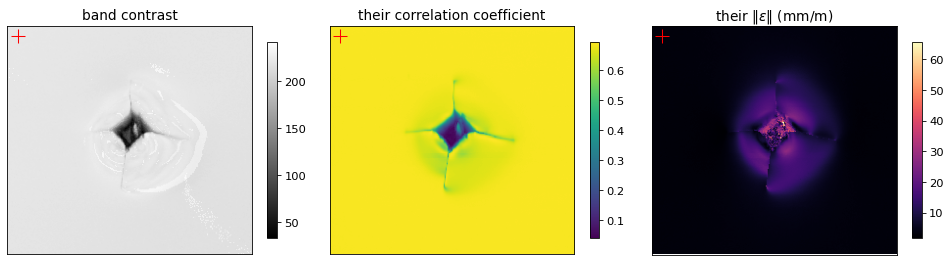

In [5]:
REFERENCE = (10, 10)  # (row, column)

if si_path:
    with h5py.File(si_path, "r") as f:
        pm = f[f"{scan}/Data Processing/Pattern Matching/Data"]
        their_ccc = np.asarray(pm["Cross Correlation Coefficient"][()]).reshape(
            map_shape
        )
        their_strain = np.asarray(pm["Strain"][()]).reshape(map_shape + (6,))
        band_contrast = np.asarray(
            f[f"{scan}/EBSD/Data/Band Contrast"][()]
        ).reshape(map_shape)
        cal = f[
            f"{scan}/Data Processing/Pattern Matching/Header/"
            "Pattern Center Calibration"
        ]
        keys = [k for k in cal if isinstance(cal[k], h5py.Group)]
        pos_x = np.array([np.ravel(cal[k]["Position X"][()])[0] for k in keys])
        pos_y = np.array([np.ravel(cal[k]["Position Y"][()])[0] for k in keys])

    argmax = np.unravel_index(np.argmax(their_ccc), map_shape)
    print(
        f"their cross correlation coefficient: {their_ccc.min():.4f} to "
        f"{their_ccc.max():.4f}, median {np.median(their_ccc):.4f}"
    )
    print(
        f"  points at 1.0: {int((their_ccc >= 1.0).sum())}, "
        f"at 0.999 or above: {int((their_ccc >= 0.999).sum())}, "
        f"maximum at row {argmax[0]}, column {argmax[1]}"
    )

    trace = their_strain[..., :3].sum(axis=-1) * 1e3
    triples = {
        (i, j, k): float(
            np.abs(their_strain[..., [i, j, k]].sum(axis=-1)).max() * 1e3
        )
        for i in range(6)
        for j in range(i + 1, 6)
        for k in range(j + 1, 6)
    }
    best, second = sorted(triples, key=triples.get)[:2]
    print(
        f"their columns {best} sum to zero to {np.abs(trace).max():.4f} "
        f"mm/m worst case and {np.std(trace):.5f} mm/m rms, against "
        f"{triples[second]:.4f} mm/m for the next best triple {second}: "
        "those three are the normal strains of a traceless field"
    )
    print(
        "their strain at our reference (mm/m):",
        np.round(their_strain[REFERENCE] * 1e3, 3),
    )
    print(
        f"calibration Position X {pos_x.min()} to {pos_x.max()} against "
        f"{map_shape[1]} columns, Position Y {pos_y.min()} to {pos_y.max()} "
        f"against {map_shape[0]} rows, over {len(keys)} calibration points"
    )

    their_norm = np.linalg.norm(their_strain, axis=-1) * 1e3
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, values, title, cmap in zip(
        axes,
        (band_contrast, their_ccc, their_norm),
        (
            "band contrast",
            "their correlation coefficient",
            r"their $\|\varepsilon\|$ (mm/m)",
        ),
        ("gray", "viridis", "magma"),
    ):
        image = ax.imshow(values, cmap=cmap)
        ax.plot(REFERENCE[1], REFERENCE[0], "r+", ms=14)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(image, ax=ax, shrink=0.8)
    fig.tight_layout()

## The band-pass, decided by measurement

`filter_cutoffs` is the band-pass the engine applies inside the fitting
loop, to the reference and to every target alike.
Its default `(0.05, None)`, a high-pass with no low-pass, is measured on
noise free synthetic patterns in the
[HR-EBSD tutorial](hrebsd_dic.ipynb), where it costs rotation capture
range: 2.0 degrees against 4.0 degrees with no filtering at all.

This map needs more capture range than that.
A nanoindent rotates the lattice by tens of milliradians, and 50 mrad is
2.9 degrees, so the pick rule is stated before the numbers:

> take `(None, None)` because the map needs at least 3 degrees of
> capture range, unless its noise floor is catastrophically worse, more
> than twice the floor of the default, in which case the choice still
> stands but the penalty is reported as a finding.

The 50 mrad is an estimate, and this map beats it: the largest lattice
rotation measured below is 87.1 mrad, 4.99 degrees, past even the
unfiltered 4.0 degrees.
That is not the contradiction it looks like.
The synthetic figure is for a pure **in-plane** rotation, a turn of the
pattern about its own normal, which nothing in the initial guess can
undo; a lattice rotation about an in-plane axis mostly *translates* the
pattern instead, by $\omega \times \mathrm{DD}$ pixels, and every fit
is seeded per point by a phase cross-correlation that measures exactly
that translation.
The projection centre section below does that arithmetic on the
deformed zone.

The floor is measured with the paper's own estimator, its eqs 17 and 18:
on a strain free row, the standard deviation of the difference between
neighbouring points, divided by $\sqrt{2}$.
The paper uses row 10 of this map for it, and so do we, on all 250 of
its points, under both settings.
The estimator is applied to each of the six deviatoric strain components
and each of the three rotation components separately.

One caveat travels with every use of this estimator below: it measures
point to point *scatter*, so it is a floor on random noise and blind to
anything that varies smoothly across the map.

In [6]:
def sigma_neighbour_pair(values, valid):
    "Noise from successive along-row differences (paper eqs 17 and 18)."
    pair = valid[..., :-1] & valid[..., 1:]
    d = np.diff(values, axis=-1)[pair]
    return float(np.std(d) / np.sqrt(2)) if d.size > 3 else float("nan")


VOIGT = [(0, 0), (1, 1), (2, 2), (1, 2), (0, 2), (0, 1)]
NAMES = ["e11", "e22", "e33", "e23", "e13", "e12"]


def to_tensor(voigt):
    "Return the (..., 3, 3) tensors of (..., 6) Voigt vectors."
    t = np.zeros(voigt.shape[:-1] + (3, 3))
    for k, (i, j) in enumerate(VOIGT):
        t[..., i, j] = voigt[..., k]
        t[..., j, i] = voigt[..., k]
    return t


def to_voigt(tensor):
    "Return the (..., 6) Voigt vectors of (..., 3, 3) tensors."
    return np.stack([tensor[..., i, j] for i, j in VOIGT], axis=-1)


def strain_invariants(voigt, remove_trace=True):
    "Return K2, K3 and the count of K3 outside [-1, 1] before clipping."
    # K3 is the Lode cosine of a DEVIATOR. The strain reported by the
    # deviatoric closure is not one: the closure sets the trace of the
    # distortion to zero, and the polar decomposition then leaves a
    # second order trace in the strain. It is removed here first, and
    # remove_trace=False is offered only to show what that costs
    values = np.asarray(voigt, dtype=float).copy()
    if remove_trace:
        values[..., :3] -= values[..., :3].sum(axis=-1, keepdims=True) / 3
    tensor = to_tensor(values)
    j2 = 0.5 * np.sum(tensor * tensor, axis=(-2, -1))
    with np.errstate(invalid="ignore", divide="ignore"):
        k3 = 1.5 * np.sqrt(3.0) * np.linalg.det(tensor) / j2**1.5
    outside = int(np.sum(np.abs(k3) > 1.0 + 1e-9))
    return np.sqrt(2.0 * j2), np.clip(k3, -1.0, 1.0), outside


def plot_maps(maps, titles, cmaps="viridis", labels="", ncols=3, vlims=None):
    "Plot map shaped arrays side by side, NaN in grey."
    n = len(maps)
    cmaps = cmaps if isinstance(cmaps, list) else [cmaps] * n
    labels = labels if isinstance(labels, list) else [labels] * n
    vlims = vlims if isinstance(vlims, list) else [vlims] * n
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4.1 * ncols, 3.4 * nrows), squeeze=False
    )
    axes = np.ravel(axes)
    for ax, values, title, name, label, vlim in zip(
        axes, maps, titles, cmaps, labels, vlims
    ):
        cmap = plt.get_cmap(name).copy()
        cmap.set_bad("0.75")
        vmin, vmax = vlim if vlim is not None else (None, None)
        image = ax.imshow(values, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(image, ax=ax, shrink=0.8, label=label)
    for ax in axes[n:]:
        ax.axis("off")
    fig.tight_layout()

In [7]:
if si_path:
    row10 = np.ones(map_shape, dtype=bool)
    row10[10] = False  # False means correlate, True means skip
    n_row10 = int((~row10).sum())
    trials = {}
    for cutoffs in [(0.05, None), (None, None)]:
        start = time.time()
        xmap_row = s.hrebsd_dic(
            xmap_in,
            detector,
            reference=REFERENCE,
            filter_cutoffs=cutoffs,
            navigation_mask=row10,
            chunksize=16,
            verbose=0,
        )
        seconds = time.time() - start
        row = hrebsd_strain_stress(xmap_row, detector, closure="deviatoric")
        good = np.asarray(xmap_row.prop["converged"]).reshape(map_shape)[10]
        eps = np.asarray(row.prop["strain"]).reshape(map_shape + (6,))[10] * 1e3
        omega = (
            np.asarray(row.prop["rotation_vector"]).reshape(map_shape + (3,))[10]
            * 1e3
        )
        good &= np.all(np.isfinite(eps), axis=-1)
        trials[cutoffs] = {
            "converged": int(good.sum()),
            "rate": n_row10 / seconds,
            "sigma_eps": [sigma_neighbour_pair(eps[:, i], good) for i in range(6)],
            "sigma_omega": [
                sigma_neighbour_pair(omega[:, i], good) for i in range(3)
            ],
        }

    print(
        f"row 10, {n_row10} points, the paper's own strain free row\n"
    )
    print(
        f"{'filter_cutoffs':16s} {'converged':>10s} {'rate':>10s} "
        f"{'median sigma_eps':>18s} {'median sigma_theta':>20s}"
    )
    for cutoffs, t in trials.items():
        print(
            f"{str(cutoffs):16s} {t['converged']:>6d}/{n_row10} "
            f"{t['rate']:>7.2f}/s {np.median(t['sigma_eps']):>15.4f} mm/m "
            f"{np.median(t['sigma_omega']):>15.4f} mrad"
        )
    print()
    for cutoffs, t in trials.items():
        print(
            f"{str(cutoffs):16s} per component sigma_eps (mm/m): "
            + " ".join(f"{n}={v:.4f}" for n, v in zip(NAMES, t['sigma_eps']))
        )
    ratio = np.median(trials[(None, None)]["sigma_eps"]) / np.median(
        trials[(0.05, None)]["sigma_eps"]
    )
    print(
        f"\nfloor of (None, None) relative to the default: {ratio:.3f}, "
        f"so the penalty clause of the pick rule "
        f"{'applies' if ratio > 2 else 'does not apply'}"
    )

row 10, 250 points, the paper's own strain free row

filter_cutoffs    converged       rate   median sigma_eps   median sigma_theta
(0.05, None)        250/250    8.12/s          0.0287 mm/m          0.0277 mrad
(None, None)        250/250    9.15/s          0.0267 mm/m          0.0258 mrad

(0.05, None)     per component sigma_eps (mm/m): e11=0.0497 e22=0.0246 e33=0.0495 e23=0.0270 e13=0.0175 e12=0.0304
(None, None)     per component sigma_eps (mm/m): e11=0.0475 e22=0.0236 e33=0.0465 e23=0.0246 e13=0.0160 e12=0.0287

floor of (None, None) relative to the default: 0.929, so the penalty clause of the pick rule does not apply


No penalty at all: with no filtering the floor is slightly *better* on
both quantities, and the decision is already over determined by the
capture range argument.

The next cell makes it unanimous, and measures a second setting that
turns out to matter more.
It runs a 5 by 5 patch on the south rim of the indent, where the lattice
rotation is tens of milliradians, in three configurations.

* The default band-pass with a generous iteration budget.
* No band-pass with the **default** `max_iterations=50`.
* No band-pass with `max_iterations=500`.

The second of these is the trap of this data set.
A fit stops when the corner displacement of one iteration falls below
`min_step`, 1e-3 pixel; on far field patterns that takes about ten
iterations, and on the deformed rim it takes over a hundred.
At the default budget the deformed half of this map returns *nothing*,
and it does so without failing loudly: the fit has already reached the
right answer, the residual and the translations at iteration 50 are the
same as at iteration 500, it simply has not yet driven the increment
below the threshold and so reports `converged=False`.
Non-converged points carry NaN in every derived property, so an unwary
run comes back with an empty deformed zone and a full far field.

In [8]:
if si_path:
    rim = (slice(125, 130), slice(115, 120))
    rim_mask = np.ones(map_shape, dtype=bool)
    rim_mask[rim] = False

    print("the indent's south rim, 25 points\n")
    print(
        f"{'filter_cutoffs':16s} {'iterations':>11s} {'converged':>11s} "
        f"{'median |omega|':>15s} {'median residual':>16s} {'median steps':>13s}"
    )
    configurations = [
        ((0.05, None), 500),
        ((None, None), 50),
        ((None, None), 500),
    ]
    for cutoffs, budget in configurations:
        xmap_rim = s.hrebsd_dic(
            xmap_in,
            detector,
            reference=REFERENCE,
            filter_cutoffs=cutoffs,
            max_iterations=budget,
            navigation_mask=rim_mask,
            chunksize=8,
            verbose=0,
        )
        out = hrebsd_strain_stress(xmap_rim, detector, closure="deviatoric")
        good = np.asarray(xmap_rim.prop["converged"]).reshape(map_shape)[rim]
        residual = np.asarray(xmap_rim.prop["residual"]).reshape(map_shape)[rim]
        steps = np.asarray(xmap_rim.prop["num_iterations"]).reshape(map_shape)[rim]
        omega = (
            np.asarray(out.prop["rotation_vector"]).reshape(map_shape + (3,))[rim]
            * 1e3
        )
        magnitude = np.linalg.norm(omega, axis=-1)
        median_omega = float(np.median(magnitude[good])) if good.any() else np.nan
        print(
            f"{str(cutoffs):16s} {budget:>11d} {int(good.sum()):>8d}/25 "
            f"{median_omega:>11.2f} mrad {np.median(residual):>16.3f} "
            f"{np.median(steps):>13.0f}"
        )

the indent's south rim, 25 points

filter_cutoffs    iterations   converged  median |omega|  median residual  median steps


C:\Users\westraadt.1\Repos\kikuchipy\src\kikuchipy\indexing\_hrebsd\_engine.py:1028: UserWarning: 18 of 25 pattern(s) did not converge or failed, and carry their last iterate with `converged=False` and NaN in every derived property; they are never zeroed
  warnings.warn(


(0.05, None)             500        7/25       29.28 mrad            1.412           500


C:\Users\westraadt.1\Repos\kikuchipy\src\kikuchipy\indexing\_hrebsd\_engine.py:1028: UserWarning: 25 of 25 pattern(s) did not converge or failed, and carry their last iterate with `converged=False` and NaN in every derived property; they are never zeroed
  warnings.warn(


(None, None)              50        0/25         nan mrad            0.324            50


(None, None)             500       25/25       42.08 mrad            0.312           128


The table says three things.

* The default band-pass does not merely lose capture range here, it
  loses the fit. Given the same generous iteration budget it converges a
  minority of the patch where the unfiltered fit converges all of it,
  and it does so at a residual several times worse, on rotations well
  below the unfiltered answer. `filter_cutoffs=(None, None)` is required
  on this map, not preferred.
* The default iteration budget converges nothing on the rim, at a
  residual that is already as good as the converged one: the fit is
  right and the threshold has simply not been reached.
* With both settings right, every point of the rim converges, at a
  median of over a hundred iterations.

## The run

The settings that follow from the two cells above, plus one more.

* `reference=(10, 10)`, one global reference for the whole map, in the
  strain free corner. The default `reference="auto"` would stream the
  whole 18.9 GB stack to rank image quality, and a single crystal has
  one grain anyway.
* `filter_cutoffs=(None, None)` and `max_iterations=500`, measured
  above. Raising the budget costs time only at the points that need it.
* `navigation_mask`, masking the crater itself. The indent crater is not
  measurable by digital image correlation against a far field reference:
  its patterns are destroyed, and a 10 by 10 patch at its centre
  converges one point in a hundred at a residual of 1.8. Those points
  would each burn the full iteration budget to return nothing. The mask
  is built from the authors' own correlation coefficient, below 0.35,
  which selects the crater interior. Masked points come back as NaN in
  every derived property, exactly as non-converged points do, so the
  hole in the figures below is honest either way and the mask only saves
  time.

The run takes a few hours on eight workers at this pattern size, and
the rate varies over the map by close to an order of magnitude:
patterns in the far field converge in ten to fifteen iterations,
patterns in the deformed zone in a hundred or more.
The measured rate is printed with the result rather than promised here.

In [9]:
if si_path:
    crater = their_ccc < 0.35  # True means skipped by the correlation
    n_fit = int((~crater).sum())
    print(
        f"masking {int(crater.sum())} crater points, correlating {n_fit} of "
        f"{crater.size}"
    )

    start = time.time()
    xmap_dic = s.hrebsd_dic(
        xmap_in,
        detector,
        reference=REFERENCE,
        filter_cutoffs=(None, None),
        max_iterations=500,
        navigation_mask=crater,
        chunksize=16,
        verbose=0,
    )
    run_seconds = time.time() - start

    converged = np.asarray(xmap_dic.prop["converged"]).reshape(map_shape)
    steps = np.asarray(xmap_dic.prop["num_iterations"]).reshape(map_shape)
    residual = np.asarray(xmap_dic.prop["residual"]).reshape(map_shape)
    print(
        f"{run_seconds / 3600:.2f} h, {n_fit / run_seconds:.2f} patterns/s "
        f"on {dask.config.get('num_workers')} workers"
    )
    print(
        f"converged: {int(converged.sum())} of {n_fit} correlated, "
        f"{n_fit - int(converged.sum())} did not, "
        f"{int(crater.sum())} were masked"
    )
    print(
        f"iterations: median {np.median(steps[~crater]):.0f}, "
        f"largest {int(steps.max())}"
    )
    print(f"residual: median {np.nanmedian(residual[converged]):.3f}")

masking 728 crater points, correlating 57772 of 58500


2.34 h, 6.85 patterns/s on 8 workers
converged: 57685 of 57772 correlated, 87 did not, 728 were masked
iterations: median 14, largest 500
residual: median 0.046


C:\Users\westraadt.1\Repos\kikuchipy\src\kikuchipy\indexing\_hrebsd\_engine.py:1028: UserWarning: 87 of 57772 pattern(s) did not converge or failed, and carry their last iterate with `converged=False` and NaN in every derived property; they are never zeroed
  warnings.warn(


## Strain, rotation, HR-KAM and GND

The analysis chain is the same four functions as in the
[HR-EBSD tutorial](hrebsd_dic.ipynb), and it costs a fraction of a
second on 58500 points: all of the time is in the correlation.

The closure is deviatoric, which is the strict replication of the
paper's own relative deviatoric maps.
A traction free closure, which would need a silicon stiffness and would
give an absolute stress, is a follow up.

Two invariants of the strain's deviatoric part are computed beside the
six components, for the distortion type panel of the paper's Fig. 5.
A traceless symmetric tensor needs two numbers to describe it up to
orientation, a magnitude and a type, and the ones used here are

$$K_2 = \sqrt{\varepsilon_{ij}\varepsilon_{ij}}, \qquad
K_3 = \frac{3\sqrt{3}}{2}\,
\frac{\det \varepsilon}{J_2^{3/2}}, \qquad
J_2 = \tfrac{1}{2}\varepsilon_{ij}\varepsilon_{ij} .$$

$K_3$ is the cosine of three times the Lode angle and lies between -1
and 1: it is +1 where one principal strain is positive and two are
equally negative, -1 in the mirror case, and 0 for pure shear.
Both are invariants of a *traceless* tensor, and the strain reported
above is not one, which is the one place in this notebook where the
word deviatoric has to be used carefully.
The closure sets the trace of the **distortion** to zero; the polar
decomposition that follows it then leaves a second order trace in the
**strain**, $\mathrm{tr}\,\varepsilon = |\omega|^2$, which is
negligible in the far field and reaches 7.6 mm/m where the lattice
rotation is largest, printed below.
So the helper removes the trace before forming either invariant, and
the cell below prints how many points would otherwise have come back
with $|K_3| > 1$.
The formulae are written out here rather than taken on trust, and
neither invariant is a numerically comparable reproduction of the
paper's own distortion panels, because its normalisation of them is
not reproduced verbatim.

In [10]:
BURGERS_SI = 3.84e-10  # m, a/2<110> at a = 5.4307 A

if si_path:
    start = time.time()
    result = hrebsd_strain_stress(xmap_dic, detector, closure="deviatoric")
    strain = np.asarray(result.prop["strain"]).reshape(map_shape + (6,)) * 1e3
    rotation = (
        np.asarray(result.prop["rotation_vector"]).reshape(map_shape + (3,)) * 1e3
    )
    kam = hrebsd_kam(result, order=1)
    gnd = hrebsd_gnd(result, detector, BURGERS_SI, estimator="a5")
    shift = hrebsd_pc_shift(xmap_dic, detector)
    k2, k3, outside = strain_invariants(strain)
    _, _, outside_raw = strain_invariants(strain, remove_trace=False)
    ok = converged & np.all(np.isfinite(strain), axis=-1)
    print(f"the whole chain took {time.time() - start:.2f} s")

    magnitude = np.linalg.norm(rotation[ok], axis=-1)
    print(f"usable points: {int(ok.sum())}")
    print(
        "strain, deviatoric closure (mm/m): "
        + ", ".join(
            f"{n} {np.percentile(strain[ok][:, i], 1):+.2f} to "
            f"{np.percentile(strain[ok][:, i], 99):+.2f}"
            for i, n in enumerate(NAMES)
        )
    )
    print(
        f"components inside the paper's +-15 mm/m scale: "
        f"{100 * np.mean(np.abs(strain[ok]) <= 15):.2f} per cent"
    )
    print(
        f"lattice rotation: median {np.median(magnitude):.2f} mrad, largest "
        f"{magnitude.max():.1f} mrad = {np.degrees(magnitude.max() / 1e3):.2f} deg"
    )
    trace = strain[ok][:, :3].sum(axis=-1)
    print(
        f"trace of our strain: largest {np.abs(trace).max():.3f} mm/m, rms "
        f"{np.sqrt(np.mean(trace ** 2)):.3f} mm/m, correlated with "
        f"|omega|^2 at r = {np.corrcoef(trace, magnitude ** 2)[0, 1]:.5f}"
    )
    print(
        f"K3 outside [-1, 1]: {outside} points after the trace is "
        f"removed, {outside_raw} without"
    )
    print(
        f"HR-KAM: median {np.nanmedian(kam):.3f} mrad, largest "
        f"{np.nanmax(kam):.1f} mrad"
    )
    print(
        f"GND density: median {np.nanmedian(gnd):.2e} m^-2, largest "
        f"{np.nanmax(gnd):.2e} m^-2, over {int(np.isfinite(gnd).sum())} "
        "finite points"
    )

the whole chain took 0.43 s
usable points: 57685
strain, deviatoric closure (mm/m): e11 -8.62 to +3.15, e22 -8.23 to +3.15, e33 -0.14 to +9.20, e23 -0.45 to +0.57, e13 -0.65 to +1.04, e12 -9.75 to +11.11
components inside the paper's +-15 mm/m scale: 99.94 per cent
lattice rotation: median 0.42 mrad, largest 87.1 mrad = 4.99 deg
trace of our strain: largest 7.587 mm/m, rms 0.462 mm/m, correlated with |omega|^2 at r = 1.00000
K3 outside [-1, 1]: 0 points after the trace is removed, 5025 without
HR-KAM: median 0.081 mrad, largest 39.3 mrad
GND density: median 3.76e+12 m^-2, largest 2.26e+15 m^-2, over 57535 finite points


## The maps

The panels below are at the paper's own scales, plus or minus 15 mm/m
for strain and plus or minus 50 mrad for rotation, so that they can be
put beside its Fig. 5 directly.
The largest lattice rotation on this map, 87.1 mrad, is above that
scale, so the rotation panels saturate on the crater rim rather than
showing their own maximum.
Grey is not a value: it is where the measurement does not exist, either
because the point was masked as crater or because its fit did not
converge.
The last panel of the third figure separates those two reasons.

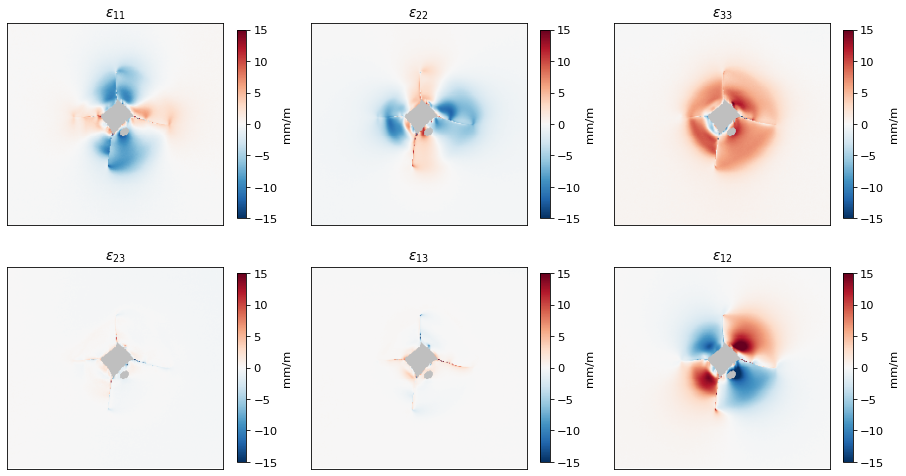

In [11]:
if si_path:
    plot_maps(
        [strain[..., i] for i in range(6)],
        [
            r"$\varepsilon_{11}$",
            r"$\varepsilon_{22}$",
            r"$\varepsilon_{33}$",
            r"$\varepsilon_{23}$",
            r"$\varepsilon_{13}$",
            r"$\varepsilon_{12}$",
        ],
        cmaps="RdBu_r",
        labels="mm/m",
        vlims=(-15, 15),
    )

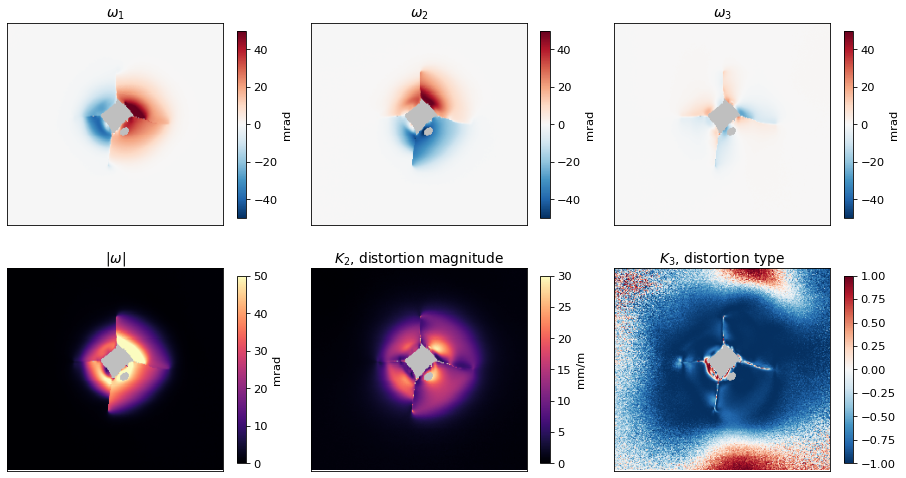

In [12]:
if si_path:
    plot_maps(
        [
            rotation[..., 0],
            rotation[..., 1],
            rotation[..., 2],
            np.linalg.norm(rotation, axis=-1),
            k2,
            k3,
        ],
        [
            r"$\omega_1$",
            r"$\omega_2$",
            r"$\omega_3$",
            r"$|\omega|$",
            r"$K_2$, distortion magnitude",
            r"$K_3$, distortion type",
        ],
        cmaps=["RdBu_r"] * 3 + ["magma", "magma", "RdBu_r"],
        labels=["mrad"] * 4 + ["mm/m", ""],
        vlims=[(-50, 50)] * 3 + [(0, 50), (0, 30), (-1, 1)],
    )

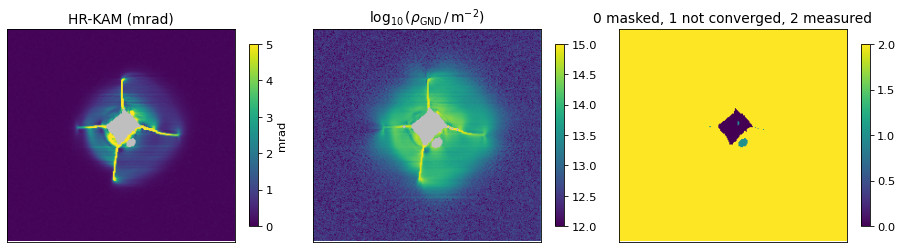

In [13]:
if si_path:
    with np.errstate(divide="ignore", invalid="ignore"):
        log_gnd = np.log10(np.where(gnd > 0, gnd, np.nan))
    status = np.where(crater, 0.0, np.where(converged, 2.0, 1.0))
    plot_maps(
        [kam, log_gnd, status],
        [
            "HR-KAM (mrad)",
            r"$\log_{10}(\rho_\mathrm{GND}\,/\,\mathrm{m}^{-2})$",
            "0 masked, 1 not converged, 2 measured",
        ],
        cmaps=["viridis", "viridis", "viridis"],
        labels=["mrad", "", ""],
        vlims=[(0, 5), (12, 15), (0, 2)],
    )

## Against their own numbers

Now the comparison the file makes possible.
Their `Strain` field and ours are both reference differenced at (10,
10) first, for the reason given at the top: theirs is absolute and
simulation referenced, ours is relative to a measured pattern, and the
difference of two points is the quantity both of them actually measure.
The paper makes the same argument about reference bias in its own
section 3.5.

Their Voigt order and their sample frame are not documented in the file.
Determining them is a small experiment, done in the pre-flight for this
tutorial and stated here as its verdict: every one of our six sample
frame components was correlated against every one of their six columns
over the deformed sub-map, and the winning assignment is not an
arbitrary permutation with three fitted sign flips.
It is **exactly one rigid rotation of the sample frame**, +90 degrees
about z: their x is our y, and their y is minus our x, in the plain
Voigt order (11, 22, 33, 23, 13, 12) with tensor shears.
All three sign flips fall out of that single rotation, which is far
stronger evidence than a permutation search on its own.
Four candidate frames tie on the correlation coefficient, which is sign
blind; the regression *slopes* separate them, and the +90 degree
rotation is the only candidate whose six slopes are all positive.

So the cell below rotates our tensors by

$$\varepsilon^{\text{theirs}} = R\,\varepsilon^{\text{ours}}\,R^{\mathrm{T}},
\qquad R = \begin{pmatrix} 0 & 1 & 0 \\ -1 & 0 & 0 \\ 0 & 0 & 1\end{pmatrix},$$

and compares component by component.
The acceptance rule, stated before the numbers: on every component
whose own standard deviation over the whole map exceeds 1 mm/m, about
forty times the noise floor measured above, the correlation coefficient
must be **positive** and exceed 0.9, and the regression slope must be
positive too.
The threshold is one on the whole map and not on a deformed patch,
which is why it is 1 and not the 2 mm/m that separated the same
components on the pre-flight's 20 by 20 sub-map: four fifths of this
map is undeformed far field, and every standard deviation over it is
diluted accordingly.
The sign matters because the frame is pinned to one specific rotation
rather than fitted: a strongly negative correlation would mean the
frame is wrong, not that the components agree.

component    our std  their std        r    slope   rms difference
e11         1.838      1.971    0.971    0.905         0.492 mm/m
e22         1.967      2.189    0.982    0.882         0.483 mm/m
e33         2.142      2.245    0.979    0.934         0.467 mm/m
e23         0.433      0.285    0.260    0.396         0.452 mm/m
e13         0.320      0.277    0.224    0.259         0.396 mm/m
e12         2.949      2.995    0.991    0.976         0.413 mm/m

well resolved components (own std above 1 mm/m): ['e11', 'e22', 'e33', 'e12']
of those, 4 of 4 pass r > 0.9 with a positive slope: ['e11', 'e22', 'e33', 'e12']
slopes positive on 6 of 6 components, the discriminator the frame was determined by: ['e11', 'e22', 'e33', 'e23', 'e13', 'e12']
whole field agreement: rms difference 0.452 mm/m, median absolute difference 0.133 mm/m
  with our rotation driven trace removed first: rms difference 0.441 mm/m


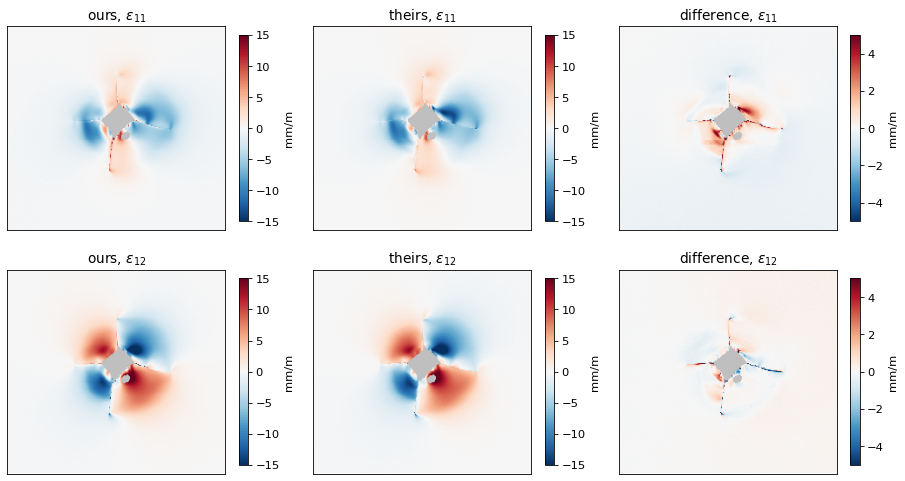

In [14]:
FRAME = np.array([[0.0, 1.0, 0.0], [-1.0, 0.0, 0.0], [0.0, 0.0, 1.0]])

if si_path:
    ours = to_voigt(FRAME @ to_tensor(strain) @ FRAME.T)
    theirs = (their_strain - their_strain[REFERENCE]) * 1e3
    # our rotation driven trace removed, for the one line below that
    # says how much of the disagreement it accounts for
    ours_deviatoric = ours.copy()
    ours_deviatoric[..., :3] -= (
        ours_deviatoric[..., :3].sum(axis=-1, keepdims=True) / 3
    )

    print(
        f"{'component':10s} {'our std':>9s} {'their std':>10s} {'r':>8s} "
        f"{'slope':>8s} {'rms difference':>16s}"
    )
    verdict = []
    for i, name in enumerate(NAMES):
        a = ours[..., i][ok]
        b = theirs[..., i][ok]
        if a.size > 3 and a.std() > 1e-12 and b.std() > 1e-12:
            r = float(np.corrcoef(a, b)[0, 1])
            slope = float(np.polyfit(b, a, 1)[0])
            rms = float(np.sqrt(np.mean((a - b) ** 2)))
        else:
            r = slope = rms = float("nan")
        print(
            f"{name:10s} {a.std():>6.3f} {b.std():>10.3f} {r:>8.3f} "
            f"{slope:>8.3f} {rms:>13.3f} mm/m"
        )
        verdict.append((name, float(a.std()), r, slope))

    resolved = [(n, r, sl) for n, sd, r, sl in verdict if sd > 1.0]
    passing = [n for n, r, sl in resolved if r > 0.9 and sl > 0]
    positive = [n for n, sd, r, sl in verdict if sl > 0]
    print(
        f"\nwell resolved components (own std above 1 mm/m): "
        f"{[n for n, _, _ in resolved]}"
    )
    if resolved:
        print(
            f"of those, {len(passing)} of {len(resolved)} pass r > 0.9 "
            f"with a positive slope: {passing}"
        )
    else:
        print(
            "no component reaches the threshold, so the rule is not "
            "tested here"
        )
    print(
        f"slopes positive on {len(positive)} of 6 components, the "
        f"discriminator the frame was determined by: {positive}"
    )
    print(
        "whole field agreement: rms difference "
        f"{np.sqrt(np.nanmean((ours[ok] - theirs[ok]) ** 2)):.3f} mm/m, "
        f"median absolute difference "
        f"{np.nanmedian(np.abs(ours[ok] - theirs[ok])):.3f} mm/m"
    )
    print(
        "  with our rotation driven trace removed first: rms difference "
        f"{np.sqrt(np.nanmean((ours_deviatoric[ok] - theirs[ok]) ** 2)):.3f}"
        " mm/m"
    )

    shown = np.where(ok[..., None], theirs, np.nan)
    panels, titles = [], []
    for i, name in ((0, r"\varepsilon_{11}"), (5, r"\varepsilon_{12}")):
        panels += [ours[..., i], shown[..., i], ours[..., i] - shown[..., i]]
        titles += [
            f"ours, ${name}$",
            f"theirs, ${name}$",
            f"difference, ${name}$",
        ]
    plot_maps(
        panels,
        titles,
        cmaps="RdBu_r",
        labels="mm/m",
        vlims=[(-15, 15), (-15, 15), (-5, 5)] * 2,
    )

## The noise floor, beside their Table 1

The paper's Table 1 reports, at this pattern resolution, a strain
resolution of 0.079 mm/m and an orientation resolution of 0.043 mrad.
Our own floors on the same row of the same map, with the same estimator,
are printed below.

The published number is not the only thing to compare against, and it
is not the closest thing either.
Their own strain field is in the file, its header records
`Refinement Binning = None`, so it is their full resolution refinement
of these same patterns, and the same estimator can be run on the same
row of it.
That is the like for like number, and the table prints it as a third
column.
It does not reproduce the published 0.079 mm/m either, which is
reported here as a fact rather than explained: what smoothing, which
quantity and which measurement Table 1's number was computed on cannot
be settled from the file, so the published figure is printed on its own
row and left unexplained rather than attributed to a cause this
notebook has not measured.
The table's two per component rows are each in their own frame, ours
in the frame of our fit and theirs in the one the comparison section
pins to a 90 degree rotation of it, so those two rows compare as sets
and not entry against entry; the medians above them are over all six
components of each.

The GND floor is read the same way.
A far field median of a few times 1e12 m^-2 sits under the 4e12 to
8e12 m^-2 class quoted for HR-EBSD at fine steps, which is the right
neighbourhood for nominally dislocation free silicon measured at a 0.2
um step, and the deformed zone reaches orders of magnitude above it.

In [15]:
# a 20 by 50 strain free block in the corner, which contains 50 of the
# 250 points of the paper's row 10; the sigma columns below are
# measured on all 250 of that row instead, in the band-pass cell above
FAR = (slice(0, 20), slice(0, 50))

if si_path:
    far = np.zeros(map_shape, dtype=bool)
    far[FAR] = True
    far &= ok

    sigma_eps = trials[(None, None)]["sigma_eps"]
    sigma_omega = trials[(None, None)]["sigma_omega"]
    their_row = (their_strain[10] - their_strain[REFERENCE]) * 1e3
    all_of_it = np.ones(map_shape[1], dtype=bool)
    their_sigma = [
        sigma_neighbour_pair(their_row[:, i], all_of_it) for i in range(6)
    ]
    print("noise floor, row 10, the estimator of the paper's eqs 17 and 18\n")
    print(
        f"{'quantity':22s} {'ours, measured':>15s} "
        f"{'theirs, measured':>17s} {'theirs, published':>18s}"
    )
    print(
        f"{'strain, median':22s} {np.median(sigma_eps):>10.4f} mm/m "
        f"{np.median(their_sigma):>12.4f} mm/m {0.079:>13.3f} mm/m"
    )
    print(
        f"{'rotation, median':22s} {np.median(sigma_omega):>10.4f} mrad "
        f"{'not in the file':>17s} {0.043:>13.3f} mrad"
    )
    print(
        f"{'strain, ours':22s} "
        + " ".join(f"{n}={v:.4f}" for n, v in zip(NAMES, sigma_eps))
    )
    print(
        f"{'strain, theirs':22s} "
        + " ".join(f"{n}={v:.4f}" for n, v in zip(NAMES, their_sigma))
    )
    print(
        "\nthe middle column is their own delivered field, on the same "
        "row, through the same\nestimator, so it is the like for like "
        "number; the published one is neither\nreproduced by it nor "
        "explained here"
    )

    print(
        f"\nfar field ({int(far.sum())} points of the strain free corner)"
    )
    print(
        f"  largest |strain| {np.nanmax(np.abs(strain[far])):.3f} mm/m, "
        f"largest |rotation| "
        f"{np.nanmax(np.linalg.norm(rotation[far], axis=-1)):.3f} mrad"
    )
    print(
        f"  HR-KAM median {np.nanmedian(kam[far]):.4f} mrad, GND median "
        f"{np.nanmedian(gnd[far]):.2e} m^-2 against a literature class of "
        "4e12 to 8e12 m^-2"
    )
    print(
        f"  deformed zone GND reaches {np.nanmax(gnd):.2e} m^-2, "
        f"{np.nanmax(gnd) / np.nanmedian(gnd[far]):.0f} times the far field "
        "floor"
    )
    print(
        f"\nthroughput: {n_fit / run_seconds:.2f} patterns/s on 8 CPU workers "
        "at 622 by 512 px,\nagainst the paper's own figure of about 20 "
        "patterns/s on two RTX 4090 GPUs"
    )

noise floor, row 10, the estimator of the paper's eqs 17 and 18

quantity                ours, measured  theirs, measured  theirs, published
strain, median             0.0267 mm/m       0.0438 mm/m         0.079 mm/m
rotation, median           0.0258 mrad   not in the file         0.043 mrad
strain, ours           e11=0.0475 e22=0.0236 e33=0.0465 e23=0.0246 e13=0.0160 e12=0.0287
strain, theirs         e11=0.0278 e22=0.0584 e33=0.0593 e23=0.0253 e13=0.0474 e12=0.0403

the middle column is their own delivered field, on the same row, through the same
estimator, so it is the like for like number; the published one is neither
reproduced by it nor explained here

far field (1000 points of the strain free corner)
  largest |strain| 0.221 mm/m, largest |rotation| 0.216 mrad
  HR-KAM median 0.0610 mrad, GND median 2.49e+12 m^-2 against a literature class of 4e12 to 8e12 m^-2
  deformed zone GND reaches 2.26e+15 m^-2, 906 times the far field floor

throughput: 6.85 patterns/s on 8 CPU workers at

## The projection centre diagnostic

[hrebsd_pc_shift()](../reference/generated/kikuchipy.indexing.hrebsd_pc_shift.rst)
compares the rigid translation each fit measured with the translation
the beam scan geometry predicts from the per-point projection centres.
Its residual is a projection centre diagnostic **only where the lattice
is undeformed**, because a lattice rotation moves the pattern too: a
rotation $\omega$ about an in-plane axis shifts it by
$\omega \times \mathrm{DD}$ pixels, and at this detector distance a
rotation of 32 mrad is a shift of 12 pixels.

So the plane is fitted on the strain free corner only, as the docstring
says, and the deformed zone number is printed beside it with that
arithmetic done, to show that it is lattice signal rather than
miscalibration.

The far field residual is the interesting number: it tests the paper's
affine projection centre calibration and our per-point-PC geometry
against each other, on measured translations of about a tenth of a
pixel.

In [16]:
if si_path:
    fit_mask = (
        far
        & np.isfinite(shift["residual_x"])
        & np.isfinite(shift["residual_y"])
    )
    grid_rows, grid_cols = np.mgrid[0 : map_shape[0], 0 : map_shape[1]]
    design = np.column_stack(
        [np.ones(int(fit_mask.sum())), grid_cols[fit_mask], grid_rows[fit_mask]]
    )
    print(
        f"strain free corner, {int(fit_mask.sum())} points, in binned pixels\n"
    )
    for key in ("translation_x", "translation_y", "residual_x", "residual_y"):
        values = shift[key][fit_mask]
        line = (
            f"{key:14s} median {np.nanmedian(values):+8.4f}  rms "
            f"{np.sqrt(np.nanmean(values**2)):8.4f}"
        )
        if key.startswith("residual"):
            coefficients, *_ = np.linalg.lstsq(design, values, rcond=None)
            line += (
                f"  plane {coefficients[0]:+.4f} "
                f"{coefficients[1]:+.2e} per column "
                f"{coefficients[2]:+.2e} per row"
            )
        print(line)

    deformed = ok & (np.linalg.norm(rotation, axis=-1) > 20.0)
    if deformed.any():
        dd = np.asarray(detector.pc).reshape(map_shape + (3,))[..., 2] * n_rows
        measured = np.hypot(shift["residual_x"], shift["residual_y"])[deformed]
        predicted = (
            np.linalg.norm(rotation, axis=-1)[deformed] / 1e3 * dd[deformed]
        )
        print(
            f"\ndeformed zone, {int(deformed.sum())} points above 20 mrad:"
        )
        print(
            f"  detector distance {np.median(dd[deformed]):.1f} binned px, "
            f"median |rotation| "
            f"{np.median(np.linalg.norm(rotation, axis=-1)[deformed]):.1f} mrad"
        )
        # the full rotation magnitude, so this is an upper bound: the
        # component about the surface normal shifts the pattern by
        # nothing, and no detector frame conversion is done here
        print(
            f"  residual {np.nanmedian(measured):.2f} px against at most "
            f"{np.median(predicted):.2f} px from the rotation alone: "
            "lattice signal, not miscalibration"
        )

strain free corner, 1000 points, in binned pixels

translation_x  median  -0.0759  rms   0.1086
translation_y  median  -0.0150  rms   0.0262
residual_x     median  -0.0011  rms   0.0082  plane -0.0009 -1.34e-04 per column +3.78e-04 per row
residual_y     median  -0.0166  rms   0.0203  plane -0.0180 -4.19e-04 per column +1.25e-03 per row

deformed zone, 4489 points above 20 mrad:
  detector distance 379.6 binned px, median |rotation| 32.4 mrad
  residual 12.13 px against at most 12.28 px from the rotation alone: lattice signal, not miscalibration


## What this replication does and does not show

* **The comparison is against one other implementation, not against
  truth.** Neither field is a ground truth for the other. What the
  agreement establishes is that two independent implementations, one
  fitting a simulated master pattern and one fitting a measured
  reference pattern, measure the same deviatoric strain field on the
  same patterns to about half a millimetre per metre.
* **The two out-of-plane shears are the weak pair.** They carry the
  smallest amplitude of the six components on this map, and they are the
  pair that HR-EBSD trades against the rigid translation of the fit, so
  a lower correlation there is expected rather than a failure of the
  frame determination. The table above prints them honestly.
* **The crater is not a result.** It is masked, and its rim points that
  did not converge are NaN. Nothing in this notebook interpolates over
  either.
* **Deviatoric closure, no stress.** The absolute stress would need a
  traction free closure and a silicon stiffness, and it is deferred with
  the super-resolution follow up.
* **The closure is on the distortion, so the strain is not traceless.**
  Their field's normal components sum to zero to 0.08 mm/m rms, 2.3
  mm/m at worst; ours carry
  $\mathrm{tr}\,\varepsilon = |\omega|^2$, printed above, which is
  nothing in the far field and 7.6 mm/m at the largest lattice
  rotation, spread isotropically over the three normal components.
  Part of the component by component disagreement above is therefore
  our own closure rather than a real difference, which is why the trace
  removed agreement is printed beside it.
* **Everything is relative to one pattern.** Every number above is a
  difference from the pattern at (10, 10), so a strain uniform over the
  whole map, and the reference's own strain, are both unmeasurable
  here. Their absolute field puts our reference at
  [1.18, -2.33, 1.15, -0.61, -0.16, 0.31] mm/m, printed above, so our
  zero is demonstrably not zero strain.
* **One map, one indent, no repeat.** This is a single acquisition of a
  single indent, compared against a single other implementation. No
  quantity here has a spread over repeats behind it.
* **The noise floors are a floor on random scatter.** The neighbour pair
  estimator is blind to anything that varies smoothly across the map, so
  it does not bound a systematic error, such as an uncorrected optical
  distortion of the detector.
* **No optical distortion correction.** As in the
  [HR-EBSD tutorial](hrebsd_dic.ipynb), the correction of Ernould et al.
  (2021) is not implemented, which matters most for strains in the 1e-4
  to 2e-3 band on lens coupled detectors.
* **The deferred half.** The paper's subject is the simulation
  supersampling that lifts the resolution beyond the native pattern
  grid. This notebook replicates the full resolution measurement only,
  and the supersampled comparison, with a like for like noise floor, is
  the follow up.

## References

* Winkelmann et al., *Ultramicroscopy* **276** (2025) 114180, the paper
  replicated here: the simulation based super-resolution method, the
  Si-indent measurement, the neighbour pair resolution estimator of its
  eqs 17 and 18 and the Table 1 numbers used above.
* Cios and Winkelmann, Zenodo record
  [14059950](https://doi.org/10.5281/zenodo.14059950), the data set:
  `AGH__Si_indent_1_512x672.h5oina`, 18.9 GB, CC-BY-4.0.
* [Wilkinson and Britton (2012)](https://doi.org/10.1016/S1369-7021(12)70163-3),
  the strain, stress and dislocation density measurement by EBSD whose
  indent conditions this scan reproduces.
* The [HR-EBSD by digital image correlation](hrebsd_dic.ipynb) tutorial
  for the method, its conventions and the literature the implementation
  is derived from.